# Task 4 - Shared preprocessing for visual similarity search

## What preprocessing establishes for Task 4

For Task 4, preprocessing is where the general idea of “find similar products” becomes a reproducible retrieval problem. The catalogue provides product images together with `articleType` and `gender`, so the working relevance rule treats two items as relevant when these two attributes match. This is deliberately a semantic proxy: it gives every experiment a consistent target, although it cannot represent every perceptual detail such as colour, material or pattern.

The saved execution shows that the problem is large enough for representation learning—37,745 products and 249 joint classes—but also strongly long-tailed. Thirty training classes contain fewer than two items, and three label combinations appear only in the outer test set. These observations determine the later modelling choices: the test set must remain sealed, rare classes need an explicit eligibility rule, and supervised metric-learning batches must be constructed so that anchors actually receive positive examples.

This notebook therefore creates one leakage-safe contract for the entire task. It saves the 90:10 outer split, the train-fitted joint-label encoder, and the `128 × 128` letterbox and RGB-normalisation settings. The resulting files are `splits/task4/train.csv`, `splits/task4/test.csv`, `articleType_gender_label_encoder.json`, and `image_preprocessing.json`.


### Processing mechanism

![Leakage-safe preprocessing flow](figures/00_preprocessing_flow.svg)

*Figure 1. The test split is sealed before the label vocabulary and RGB statistics are fitted. The stratification step follows the iterative multilabel principle in [1].*


## 1. Environment and configuration

The project-root search lets the notebook run from either the repository root or `notebooks/task4`. Shared constants come from `src.task4.config`, so paths, seed, image size, and label names cannot silently drift between experiments. Output directories are created here because the next six notebooks treat these files as required inputs.


In [ ]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
while (
    PROJECT_ROOT != PROJECT_ROOT.parent
    and not (PROJECT_ROOT / "pyproject.toml").exists()
):
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit

from src.task4.config import (
    CONFIG_DIR,
    DATA_PATH,
    LABEL_COLUMN,
    LABEL_ID_COLUMN,
    SPLIT_DIR,
)
from src.task4.preprocessing import compute_rgb_mean_std


In [3]:
SPLIT_DIR.mkdir(parents=True, exist_ok=True)
CONFIG_DIR.mkdir(parents=True, exist_ok=True)

## 2. Inspect the source metadata

The retrieval proxy requires a valid image `id`, `articleType`, and `gender`. Schema, data types, row count, and missingness are checked before splitting so that an invalid target cannot enter the encoder. This is a metadata preflight only: ID uniqueness, unreadable images, and duplicate groups must already have been handled by the upstream EDA/preprocessing pipeline.


In [4]:
df = pd.read_csv(DATA_PATH)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 37745 entries, 0 to 37744
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   id                  37745 non-null  int64
 1   gender              37745 non-null  str  
 2   masterCategory      37745 non-null  str  
 3   subCategory         37745 non-null  str  
 4   articleType         37745 non-null  str  
 5   baseColour          37745 non-null  str  
 6   season              37745 non-null  str  
 7   year                37745 non-null  int64
 8   usage               37745 non-null  str  
 9   productDisplayName  37745 non-null  str  
dtypes: int64(2), str(8)
memory usage: 2.9 MB


### Interpretation

The dataset contains **37,745 product records and 10 metadata columns**. All displayed columns are complete, including the image identifier, product type, and gender fields required by the retrieval task. No missing-value imputation is therefore required for the current metadata.

> `df.info()` does not establish whether IDs are unique or whether every referenced image exists; those conditions should be validated separately if the source dataset changes.


## 3. Create the outer train-test split

Ten percent of the catalogue is reserved once for final evaluation. Iterative multilabel stratification is applied to one-hot `articleType` and `gender` indicators because it preserves both marginal label distributions better than an unconstrained random split when labels are imbalanced [1]. The fixed seed makes membership reproducible.

This method does **not** guarantee every rare joint combination appears on both sides. That limitation is measured explicitly rather than repaired with test information. The outer test set is never used for hyperparameter search, epoch selection, or preprocessing estimates.


In [5]:
stratify_cols = [
    "articleType",
    "gender",
]

stratify_features = pd.get_dummies(
    df[stratify_cols].astype(str),
    prefix=stratify_cols,
)

splitter = MultilabelStratifiedShuffleSplit(
    n_splits=1,
    test_size=0.10,
    random_state=42,
)

outer_train_idx, test_idx = next(splitter.split(df, stratify_features))
outer_train_df = df.iloc[outer_train_idx].copy()
test_df = df.iloc[test_idx].copy()

print("Train:", outer_train_df.shape)
print("Test: ", test_df.shape)

Train: (33968, 10)
Test:  (3777, 10)


### Interpretation

The split assigns **33,968 products to training** and **3,777 products to testing**, matching the intended 90:10 proportion. This provides a large development set while preserving an independent sample for final retrieval evaluation.

The stratification balances `articleType` and `gender` individually, but it does not guarantee that every joint `articleType × gender` combination appears in training. Joint-label coverage is checked next.


## 4. Construct the retrieval relevance proxy

Two images are counted as relevant when their cleaned `articleType__gender` values match. For example, a men's T-shirt and another men's T-shirt are relevant under this rule, whereas a men's T-shirt and a women's T-shirt are not, even if their colour and cut look similar. `articleType` supplies the main semantic shape and function cue, while `gender` prevents visually related but differently targeted catalogue groups from being merged.

The label encoder is fitted only on outer-training rows. A joint label that exists only in the hold-out therefore stays unknown instead of being added retrospectively to the vocabulary. This avoids leakage, but it also makes the scope clear: the benchmark measures closed-set semantic retrieval rather than a complete solution to cold-start similarity.

The proxy is useful because it is consistent and available for every image; it is not assumed to be perfect perceptual ground truth. Items within one class can still differ in colour, pattern, material and silhouette, while items assigned to different labels may look alike. Ranked metrics and qualitative examples are therefore needed later instead of classification accuracy alone [2].


In [ ]:
for split_df in (outer_train_df, test_df):
    split_df[LABEL_COLUMN] = (
        split_df["articleType"].str.strip() + "__" + split_df["gender"].str.strip()
    )

classes = sorted(outer_train_df[LABEL_COLUMN].unique().tolist())
label_to_index = {label: index for index, label in enumerate(classes)}
outer_train_df[LABEL_ID_COLUMN] = (
    outer_train_df[LABEL_COLUMN].map(label_to_index).astype("int64")
)
test_df[LABEL_ID_COLUMN] = test_df[LABEL_COLUMN].map(label_to_index).astype("Int64")

unseen_test_labels = sorted(set(test_df[LABEL_COLUMN]) - set(label_to_index))
if unseen_test_labels:
    print(
        f"Warning: {len(unseen_test_labels)} test label(s) are absent from training and have <NA> IDs."
    )
    print(unseen_test_labels)

with (CONFIG_DIR / "articleType_gender_label_encoder.json").open(
    "w", encoding="utf-8"
) as file:
    json.dump(
        {
            "label_column": LABEL_COLUMN,
            "label_id_column": LABEL_ID_COLUMN,
            "fit_split": "train",
            "separator": "__",
            "classes": classes,
            "label_to_index": label_to_index,
        },
        file,
        indent=2,
        sort_keys=True,
    )

outer_train_df.to_csv(SPLIT_DIR / "train.csv", index=False)
test_df.to_csv(SPLIT_DIR / "test.csv", index=False)

class_counts = outer_train_df[LABEL_COLUMN].value_counts()
print(f"Saved {len(classes)} classes")
print(f"Classes with fewer than 2 training examples: {(class_counts < 2).sum()}")


['Innerwear Vests__Women', 'Shirts__Girls', 'Tracksuits__Women']
Saved 249 classes
Classes with fewer than 2 training examples: 30


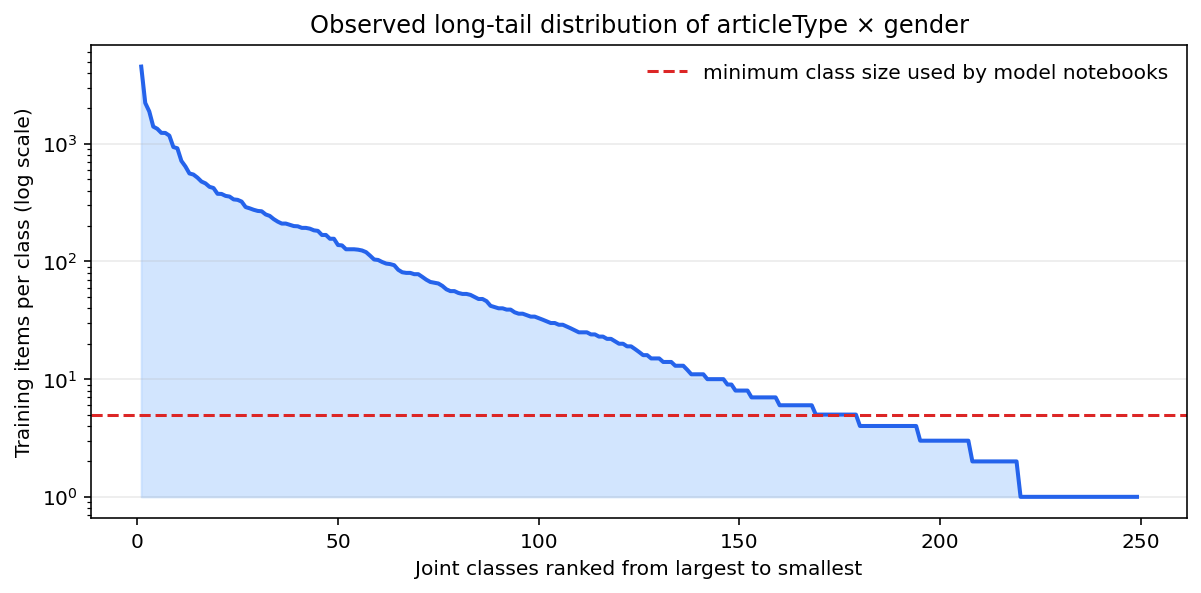

In [6]:
class_counts = outer_train_df[LABEL_COLUMN].value_counts().sort_values(ascending=False)
ranks = np.arange(1, len(class_counts) + 1)

fig, ax = plt.subplots(figsize=(8.4, 4.2))
ax.plot(ranks, class_counts.to_numpy(), color="#2563eb", linewidth=2)
ax.fill_between(ranks, class_counts.to_numpy(), 1, color="#bfdbfe", alpha=0.7)
ax.axhline(
    MIN_CLASS_SIZE if "MIN_CLASS_SIZE" in globals() else 5,
    color="#dc2626",
    linestyle="--",
    linewidth=1.5,
    label="minimum class size used by model notebooks",
)
ax.set_yscale("log")
ax.set_xlabel("Joint classes ranked from largest to smallest")
ax.set_ylabel("Training items per class (log scale)")
ax.set_title("Observed long-tail distribution of articleType × gender")
ax.grid(axis="y", alpha=0.25)
ax.legend(frameon=False)
plt.show()


### Interpretation: what the observed data changes

The long-tail curve above is not only descriptive EDA; it changes the experiment design. With 249 joint classes, Task 4 is a many-class representation-learning problem. Because 30 classes contain fewer than two training items, some rows cannot provide a same-class positive for metric learning. The later model notebooks consequently apply one declared minimum-class rule rather than allowing each method to silently train on a different population.

The imbalance also explains why ordinary random batches are unsuitable for the supervised objectives. Large classes would dominate, while an anchor from a smaller class might appear without any positive partner. P-K sampling later creates batches with four examples from each selected class, turning this observation into a concrete loader choice.

Finally, `Innerwear Vests__Women`, `Shirts__Girls`, and `Tracksuits__Women` occur only in the test split. Keeping them as `<NA>` makes the limitation visible: a closed-set gallery cannot retrieve a correct same-class item for a class it has never observed. These cases must be excluded from the common closed-set score and reported through coverage rather than forced into a known label.


## 5. Define the shared image-preprocessing contract

Each image is converted to RGB and letterboxed to `128 x 128`. Letterboxing preserves aspect ratio and therefore avoids stretching garment silhouettes; white padding matches the catalogue background better than black padding. The modest resolution keeps five from-scratch ResNet-18 experiments computationally feasible while retaining global shape and colour cues.

Metric-learning models then use channel means and standard deviations estimated **only from outer-training pixels**. The CAE instead reconstructs `[0, 1]` pixels directly because its sigmoid decoder and MSE target must share the same scale. Downstream augmentation is deliberately mild and training-only: horizontal flip plus small affine changes preserve item identity, while validation and test transforms remain deterministic.


In [ ]:
train_mean, train_std = compute_rgb_mean_std(outer_train_df["id"])
print("Training RGB mean:", np.round(train_mean, 4))
print("Training RGB std: ", np.round(train_std, 4))

image_preprocessing_config = {
    "input_color_mode": "RGB",
    "resize": {
        "method": "letterbox",
        "target_size": [128, 128],
        "interpolation": "bilinear",
        "padding_color_rgb": [255, 255, 255],
        "centering": [0.5, 0.5],
    },
    "tensor": {
        "layout": "CHW",
        "dtype": "float32",
        "value_range_before_normalization": [0.0, 1.0],
    },
    "normalization": {
        "mean_rgb": train_mean,
        "std_rgb": train_std,
    },
}

with (CONFIG_DIR / "image_preprocessing.json").open("w", encoding="utf-8") as file:
    json.dump(image_preprocessing_config, file, indent=2)

### Conclusion and hand-off

Preprocessing has done more than resize images. It has fixed what counts as relevant, separated model development from final evaluation, and revealed that the central difficulty is learning semantic neighbourhoods from a long-tailed catalogue. Every later candidate now receives the same evidence and is judged against the same target.

That conclusion suggests a useful first question. Before using the joint labels to pull products together, it is necessary to know how much similarity can be learned from the images alone. `01_convolutional_autoencoder.ipynb` therefore begins with a label-free reconstruction baseline. If that representation already separates the joint classes, more specialised supervision may be unnecessary; if it does not, its failure will identify what the next objective needs to correct.


## References

[1] K. Sechidis, G. Tsoumakas, and I. Vlahavas, "On the stratification of multi-label data," in *Machine Learning and Knowledge Discovery in Databases*, ECML PKDD, 2011, pp. 145-158, doi: [10.1007/978-3-642-23808-6_10](https://doi.org/10.1007/978-3-642-23808-6_10).

[2] C. D. Manning, P. Raghavan, and H. Schütze, *Introduction to Information Retrieval*. Cambridge, U.K.: Cambridge Univ. Press, 2008, ch. 8. [Online]. Available: https://nlp.stanford.edu/IR-book/

[3] K. He, X. Zhang, S. Ren, and J. Sun, "Deep residual learning for image recognition," in *Proc. IEEE Conf. Comput. Vis. Pattern Recognit. (CVPR)*, 2016, pp. 770-778. [Online]. Available: https://openaccess.thecvf.com/content_cvpr_2016/html/He_Deep_Residual_Learning_CVPR_2016_paper.html
